# Exploratory Data Analysis - Vendor Performance (Retail Inventory & Sales)

**Goal:** understand the four raw exports before modelling: what is in them, what is wrong with them, and which patterns matter for vendor performance, freight cost and invoice approval.

**Data note:** there is no sales file and no PO line-item file, so the analysis works from vendor invoices (one row per purchase order), the product price catalog and two inventory snapshots (2024-01-01 and 2024-12-31).

In [1]:
import sys, sqlite3, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import config as cfg

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60, "display.width", 220, "display.float_format", "{:,.2f}".format)
BLUE, ORANGE, GREEN, RED, GREY = "#1f5fae", "#ef6c00", "#2e7d32", "#c62828", "#9e9e9e"

conn = sqlite3.connect(cfg.DB_PATH)

## 1. Data overview

In [2]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"].tolist()
overview = pd.DataFrame(
    [(t, conn.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0],
      len(pd.read_sql_query(f'SELECT * FROM "{t}" LIMIT 1', conn).columns)) for t in tables],
    columns=["table", "rows", "columns"])
overview

,table,rows,columns
0,begin_inventory,206529,9
1,end_inventory,224489,9
2,purchase_prices,12261,9
3,purchases,5543,19
4,sku_margins,12261,17
5,vendor_invoice,5543,10
6,vendor_summary,132,42


In [3]:
invoice = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)
prices = pd.read_sql_query("SELECT * FROM purchase_prices", conn)
purchases = pd.read_sql_query("SELECT * FROM purchases", conn, parse_dates=["PODate", "InvoiceDate", "PayDate"])
sku = pd.read_sql_query("SELECT * FROM sku_margins", conn)
sku["ValidPricing"] = sku["ValidPricing"].astype(bool)          # SQLite stores booleans as 0/1
purchases["InPeriod"] = purchases["InPeriod"].astype(bool)
print("vendor_invoice :", invoice.shape, "| purchase_prices:", prices.shape, "| purchases:", purchases.shape, "| sku_margins:", sku.shape)
invoice.head()

vendor_invoice : (5543, 10) | purchase_prices: (12261, 9) | purchases: (5543, 19) | sku_margins: (12261, 17)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,"137,483.78","2,935.20",NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,"15,527.25",429.20,NaN


In [4]:
prices.head()

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


In [5]:
pd.read_sql_query("SELECT * FROM begin_inventory LIMIT 5", conn)

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


## 2. Data quality

In [6]:
quality = json.loads((cfg.DATA_DIR / cfg.OUT_QUALITY).read_text())
nulls = pd.DataFrame({
    "vendor_invoice": invoice.isna().sum(),
    "purchase_prices": prices.isna().sum(),
}).fillna(0).astype(int)
display(nulls[nulls.sum(axis=1) > 0])
print("Duplicate invoice rows:", invoice.duplicated().sum(), "| duplicate PO numbers:", invoice["PONumber"].duplicated().sum())
print("End-inventory rows with missing City:", quality["end_inventory_rows_missing_city"], "(all from store 46)")
print("Vendors invoiced but not in catalog:", quality["vendors_invoiced_but_not_in_catalog"])
print("Vendors in catalog without invoices:", quality["vendors_in_catalog_without_invoices"])
print("Vendors renamed during the period:", quality["vendors_renamed_during_period"])
print("Purchase orders invoiced after 2024-12-31 (kept, flagged InPeriod=False):", quality["purchase_orders_after_period_end"])

,vendor_invoice,purchase_prices
Approval,5169,0
Description,0,1
Size,0,1
Volume,0,1


Duplicate invoice rows: 0 | duplicate PO numbers: 0
End-inventory rows with missing City: 1284 (all from store 46)
Vendors invoiced but not in catalog: [201359]
Vendors in catalog without invoices: [1002, 2973, 3670, 5895, 9710, 90034]
Vendors renamed during the period: {'1587': ['VINEYARD BRANDS INC', 'VINEYARD BRANDS LLC'], '2000': ['SOUTHERN WINE & SPIRITS NE', 'SOUTHERN GLAZERS W&S OF NE']}
Purchase orders invoiced after 2024-12-31 (kept, flagged InPeriod=False): 140


The raw data is clean in structure: no duplicate POs, no negative quantities or dates out of order. The issues found are small and handled in `get_vendor_summary.py`: two vendors renamed mid-year (canonical name = most recent), one invoiced vendor with no catalog entry, six catalog vendors never invoiced, and 140 POs invoiced after the inventory window closed.

### Negative, zero and invalid values

In [7]:
bad = sku[~sku["ValidPricing"]][["Brand", "Description", "VendorName", "PurchasePrice", "CatalogRetailPrice", "RetailPrice"]]
print("SKUs with zero/invalid pricing:", len(bad))
display(bad)
neg = sku[sku["ValidPricing"] & (sku["MarginPct"] <= 0)]
print("SKUs with margin <= 0 (selling at or below cost):", len(neg), "| ending inventory at cost: $%s" % format(neg["EndValueAtCost"].sum(), ",.0f"))
display(neg.nsmallest(5, "MarginPct")[["Brand", "Description", "VendorName", "PurchasePrice", "RetailPrice", "MarginPct", "EndUnits"]])
zero_share = conn.execute("SELECT 100.0*SUM(onHand=0)/COUNT(*) FROM end_inventory").fetchone()[0]
print("Share of end-inventory store/brand rows with zero on hand: %.1f%%" % zero_share)

SKUs with zero/invalid pricing: 2


,Brand,Description,VendorName,PurchasePrice,CatalogRetailPrice,RetailPrice
7915,4202,NaN,BACARDI USA INC,11.19,0.00,0.00
10803,2166,The Macallan Double Cask 12,EDRINGTON AMERICAS,0.00,0.00,54.99


SKUs with margin <= 0 (selling at or below cost): 101 | ending inventory at cost: $366,078


,Brand,Description,VendorName,PurchasePrice,RetailPrice,MarginPct,EndUnits
5104,19138,Gerard Bertrand Organic Rose,M S WALKER INC,6.71,3.33,-101.50,1
11065,17010,Mas Sorrer Montsant Red,PERFECTA WINES,11.40,5.99,-90.32,24
9683,25584,Rex Hill Seven Soils Chard,ULTRA BEVERAGE COMPANY LLP,19.99,10.99,-81.89,6
8370,17371,Castelmaure Corbieres,PERFECTA WINES,8.84,4.99,-77.15,24
11239,22017,Foss Marai Roos Spumante Bru,VINILANDIA USA,11.64,6.79,-71.43,8


Share of end-inventory store/brand rows with zero on hand: 3.2%


## 3. Distributions

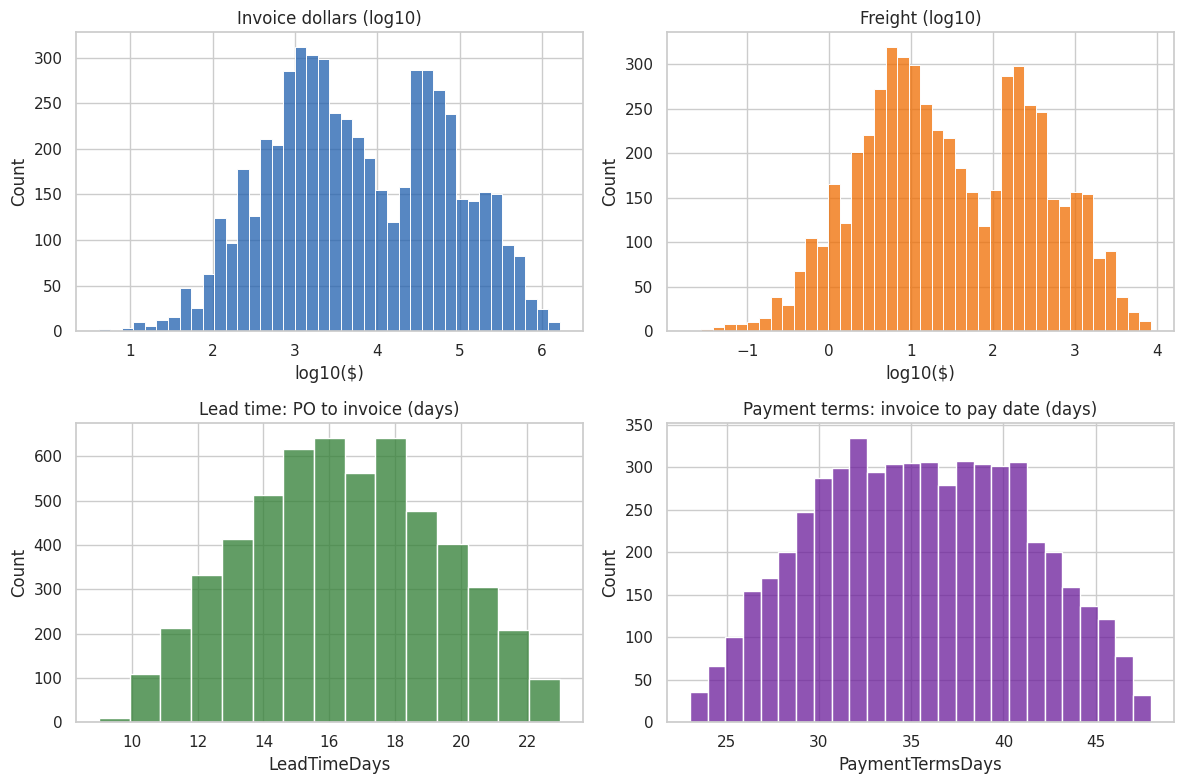

,count,mean,std,min,25%,50%,75%,max
Quantity,"5,543.00","6,058.88","14,453.34",1.00,83.00,423.00,"5,100.50","141,660.00"
Dollars,"5,543.00","58,073.38","140,234.03",4.14,967.81,"4,765.45","44,587.18","1,660,435.88"
Freight,"5,543.00",295.95,713.59,0.02,5.02,24.73,229.66,"8,468.22"
UnitCost,"5,543.00",12.38,8.14,1.10,7.75,10.06,14.56,183.95
LeadTimeDays,"5,543.00",16.42,3.13,9.00,14.00,16.00,19.00,23.00
PaymentTermsDays,"5,543.00",35.47,5.84,23.00,31.00,35.00,40.00,48.00


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(np.log10(purchases["Dollars"]), bins=40, ax=axes[0, 0], color=BLUE)
axes[0, 0].set(title="Invoice dollars (log10)", xlabel="log10($)")
sns.histplot(np.log10(purchases["Freight"]), bins=40, ax=axes[0, 1], color=ORANGE)
axes[0, 1].set(title="Freight (log10)", xlabel="log10($)")
sns.histplot(purchases["LeadTimeDays"], bins=15, ax=axes[1, 0], color=GREEN)
axes[1, 0].set(title="Lead time: PO to invoice (days)")
sns.histplot(purchases["PaymentTermsDays"], bins=26, ax=axes[1, 1], color="#6a1b9a")
axes[1, 1].set(title="Payment terms: invoice to pay date (days)")
plt.tight_layout(); plt.show()
purchases[["Quantity", "Dollars", "Freight", "UnitCost", "LeadTimeDays", "PaymentTermsDays"]].describe().T

Invoice values are extremely right-skewed (median about $4.8K, maximum $1.66M), so log scales are used throughout. Lead time (9-23 days) and payment terms (23-48 days) are tightly bounded and nearly symmetric.

## 4. Outliers: freight

count   5,543.00
mean        0.55
std         0.48
min         0.44
1%          0.45
5%          0.45
50%         0.50
95%         0.55
99%         2.72
max        11.52
Name: FreightPctOfDollars, dtype: float64
IQR upper fence: 0.620%  -> invoices above it: 86
Invoices with freight > 0.75% of invoice dollars (1.5x the standard rate): 86


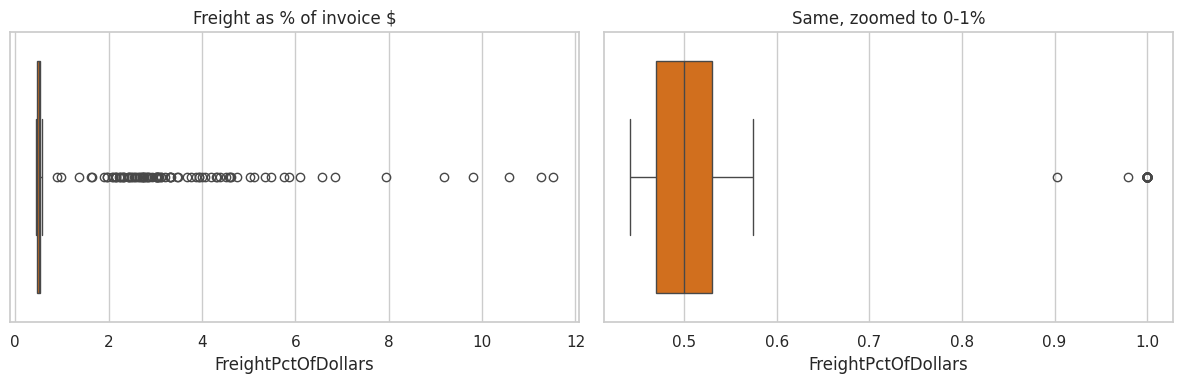

,PONumber,VendorName,InvoiceDate,Dollars,Freight,FreightPctOfDollars
32,8143,LAIRD & CO,2024-01-07,120.72,13.91,11.52
63,8206,ZORVINO VINEYARDS,2024-01-09,186.93,21.04,11.26
25,8172,CALEDONIA SPIRITS INC,2024-01-06,146.80,15.53,10.58
35,8196,KLIN SPIRITS LLC,2024-01-07,98.49,9.65,9.80
82,8198,PSP WINES,2024-01-11,66.33,6.09,9.18
39,8121,TALL SHIP DISTILLERY LLC,2024-01-08,133.26,10.59,7.95
13,8197,PREMIER DISTRIBUTORS,2024-01-05,176.11,12.08,6.86
0,8120,TAKARA SAKE USA INC,2024-01-04,55.08,3.62,6.57


In [9]:
p = purchases.copy()
print(p["FreightPctOfDollars"].describe(percentiles=[.01, .05, .5, .95, .99]).round(3))
q1, q3 = p["FreightPctOfDollars"].quantile([.25, .75]); iqr = q3 - q1
print("IQR upper fence: %.3f%%  -> invoices above it: %d" % (q3 + 1.5 * iqr, (p["FreightPctOfDollars"] > q3 + 1.5 * iqr).sum()))
print("Invoices with freight > %.2f%% of invoice dollars (1.5x the standard rate): %d" % (cfg.FREIGHT_PCT_UPPER, (p["FreightPctOfDollars"] > cfg.FREIGHT_PCT_UPPER).sum()))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=p["FreightPctOfDollars"], ax=ax[0], color=ORANGE); ax[0].set_title("Freight as % of invoice $")
sns.boxplot(x=p["FreightPctOfDollars"].clip(upper=1), ax=ax[1], color=ORANGE); ax[1].set_title("Same, zoomed to 0-1%")
plt.tight_layout(); plt.show()
p.nlargest(8, "FreightPctOfDollars")[["PONumber", "VendorName", "InvoiceDate", "Dollars", "Freight", "FreightPctOfDollars"]]

Freight is almost always 0.44%-0.55% of invoice dollars. A small group sits far above that, up to 11.5%. The timeline below shows when.

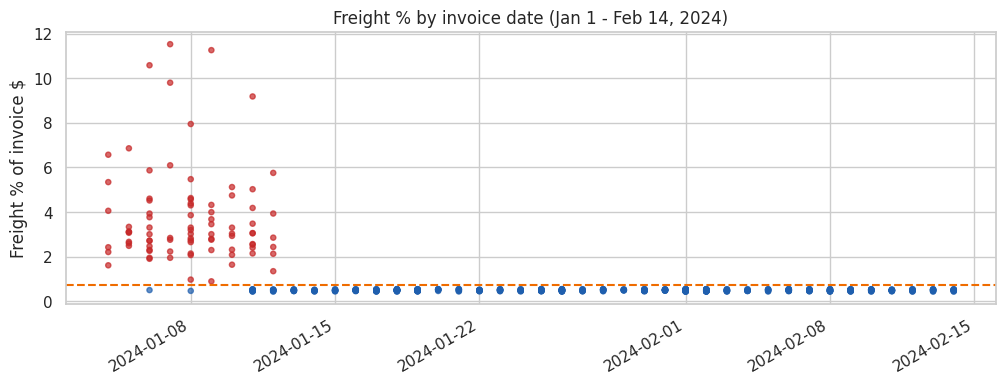

Overcharged invoices: 86 | all dated 2024-01-04 to 2024-01-12
Invoices in that window: 108, of which 80% are overcharged
Overcharged invoices outside that window: 0


In [10]:
early = p[p["InvoiceDate"] < "2024-02-15"].copy()
early["flag"] = early["FreightPctOfDollars"] > cfg.FREIGHT_PCT_UPPER
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(early["InvoiceDate"], early["FreightPctOfDollars"], c=np.where(early["flag"], RED, BLUE), s=14, alpha=.7)
ax.axhline(cfg.FREIGHT_PCT_UPPER, color=ORANGE, ls="--"); ax.set_ylabel("Freight % of invoice $")
ax.set_title("Freight % by invoice date (Jan 1 - Feb 14, 2024)"); fig.autofmt_xdate(); plt.show()
flag = p["FreightPctOfDollars"] > cfg.FREIGHT_PCT_UPPER
win = p[(p["InvoiceDate"] >= p.loc[flag, "InvoiceDate"].min()) & (p["InvoiceDate"] <= p.loc[flag, "InvoiceDate"].max())]
print("Overcharged invoices:", flag.sum(), "| all dated", p.loc[flag, "InvoiceDate"].min().date(), "to", p.loc[flag, "InvoiceDate"].max().date())
print("Invoices in that window: %d, of which %.0f%% are overcharged" % (len(win), (win["FreightPctOfDollars"] > cfg.FREIGHT_PCT_UPPER).mean() * 100))
print("Overcharged invoices outside that window:", int((flag & ~p.index.isin(win.index)).sum()))

**Finding:** every freight overcharge falls on invoices dated 4-12 January 2024, and about 80% of invoices in that window are affected. This looks like a systematic billing event (for example a surcharge or an incorrect rate table), not random noise. It is worth confirming with the vendors involved.

## 5. Correlations

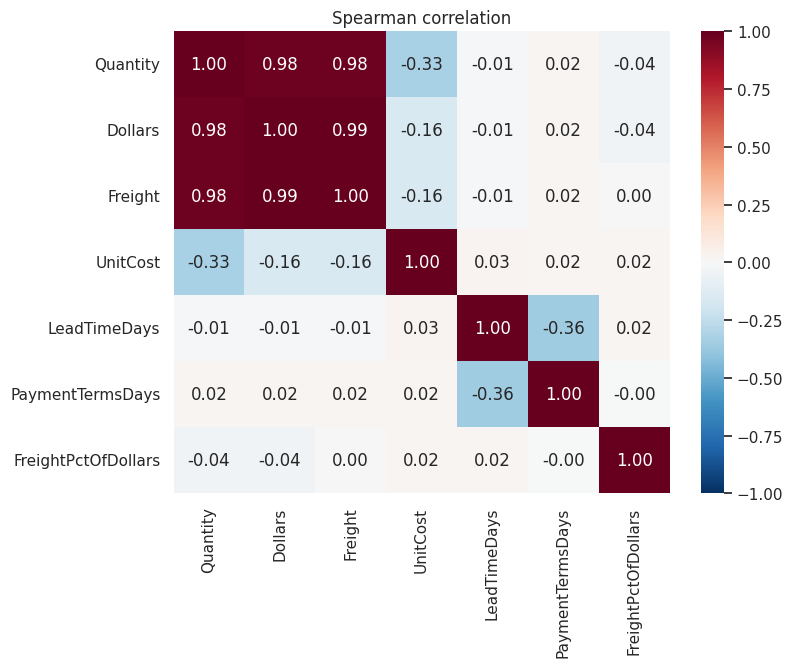

Pearson corr(Dollars, Freight) = 0.985 | corr(Quantity, Dollars) = 0.964


In [11]:
cols = ["Quantity", "Dollars", "Freight", "UnitCost", "LeadTimeDays", "PaymentTermsDays", "FreightPctOfDollars"]
corr = p[cols].corr(method="spearman")
plt.figure(figsize=(8, 6)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1); plt.title("Spearman correlation"); plt.show()
print("Pearson corr(Dollars, Freight) = %.3f | corr(Quantity, Dollars) = %.3f" % (p["Dollars"].corr(p["Freight"]), p["Quantity"].corr(p["Dollars"])))

Freight is almost perfectly correlated with invoice dollars (r = 0.985); lead time and payment terms are essentially uncorrelated with anything. Order size is the only real driver of freight, which is why the freight model reduces to a simple rate.

## 6. Purchasing over time

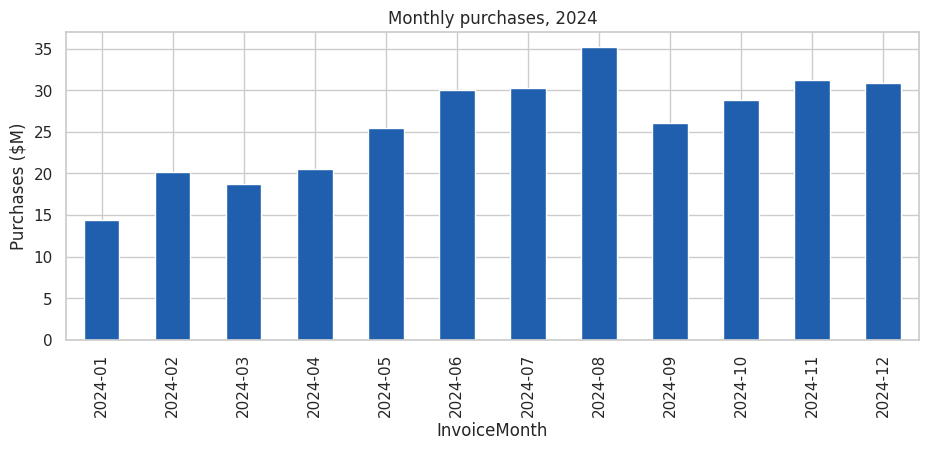

,orders,purchases_M,freight
InvoiceMonth,,,
2024-01,357,14.35,"104,658.76"
2024-02,443,20.17,"102,141.03"
2024-03,434,18.70,"92,439.07"
2024-04,429,20.49,"102,304.17"
2024-05,469,25.44,"124,994.59"
2024-06,429,29.98,"150,486.49"
2024-07,526,30.30,"152,657.72"
2024-08,466,35.24,"176,313.63"
2024-09,426,26.06,"129,074.60"


In [12]:
m = p[p["InPeriod"]].groupby("InvoiceMonth").agg(purchases=("Dollars", "sum"), orders=("PONumber", "count"), freight=("Freight", "sum"))
fig, ax = plt.subplots(figsize=(11, 4)); (m["purchases"] / 1e6).plot.bar(ax=ax, color=BLUE); ax.set_ylabel("Purchases ($M)"); ax.set_title("Monthly purchases, 2024"); plt.show()
m.assign(purchases_M=m["purchases"] / 1e6)[["orders", "purchases_M", "freight"]]

## 7. Manual approval vs invoice size

In [13]:
p["Approved"] = p["ApprovedBy"].notna()
print("Manually approved invoices:", int(p["Approved"].sum()), "of", len(p), "(%.1f%%)" % (p["Approved"].mean() * 100))
print("Approver(s):", p.loc[p["Approved"], "ApprovedBy"].unique().tolist())
print("Smallest approved invoice: $%s | largest NOT approved: $%s" % (format(p.loc[p["Approved"], "Dollars"].min(), ",.2f"), format(p.loc[~p["Approved"], "Dollars"].max(), ",.2f")))
dec = p.groupby(pd.qcut(p["Dollars"], 10)).agg(invoices=("PONumber", "count"), approved=("Approved", "sum"), approval_rate=("Approved", "mean"))
dec

Manually approved invoices: 374 of 5543 (6.7%)
Approver(s): ['Frank Delahunt']
Smallest approved invoice: $250,689.87 | largest NOT approved: $249,821.96


,invoices,approved,approval_rate
Dollars,,,
"(4.138999999999999, 259.862]",555,0,0.00
"(259.862, 697.32]",556,0,0.00
"(697.32, 1290.966]",552,0,0.00
"(1290.966, 2345.6]",554,0,0.00
"(2345.6, 4765.45]",555,0,0.00
"(4765.45, 12495.902]",554,0,0.00
"(12495.902, 33041.182]",554,0,0.00
"(33041.182, 63171.35]",554,0,0.00
"(63171.35, 172552.986]",554,0,0.00


**Finding:** manual approval is a pure dollar rule. Every invoice of about $250.7K or more was approved (by one approver) and none below $250K was, whatever its freight, unit cost or timing. Invoices with abnormal freight or unit cost were therefore never manually reviewed: see the control-gap analysis in the second notebook.

## Summary of EDA findings

In [14]:
flag = p["FreightPctOfDollars"] > cfg.FREIGHT_PCT_UPPER
display(Markdown(f"""
- **Scale:** {len(p):,} purchase orders, {p['VendorNumber'].nunique()} vendors, ${p.loc[p['InPeriod'], 'Dollars'].sum() / 1e6:,.1f}M purchased in 2024; invoice value is heavily skewed (median ${p['Dollars'].median():,.0f}, max ${p['Dollars'].max():,.0f}).
- **Data quality:** structurally clean. Minor issues: 2 renamed vendors, 1 uncatalogued vendor, 6 vendors without invoices, 2 SKUs with zero or invalid pricing, 140 POs after year-end.
- **Freight:** about {p['FreightPctOfDollars'].median():.2f}% of invoice value (r = {p['Dollars'].corr(p['Freight']):.3f}); {int(flag.sum())} invoices are overcharged, all dated 4-12 Jan 2024.
- **Approval:** a pure $250K rule ({int(p['Approved'].sum())} invoices); no anomaly-based controls were applied.
- **Lead time / payment terms:** tightly bounded ({p['LeadTimeDays'].min()}-{p['LeadTimeDays'].max()} and {p['PaymentTermsDays'].min()}-{p['PaymentTermsDays'].max()} days), almost no outliers.
- **Limitation:** no sales or PO line-item data, so unit sales and profit are estimated in the next notebook.
"""))


- **Scale:** 5,543 purchase orders, 126 vendors, $311.6M purchased in 2024; invoice value is heavily skewed (median $4,765, max $1,660,436).
- **Data quality:** structurally clean. Minor issues: 2 renamed vendors, 1 uncatalogued vendor, 6 vendors without invoices, 2 SKUs with zero or invalid pricing, 140 POs after year-end.
- **Freight:** about 0.50% of invoice value (r = 0.985); 86 invoices are overcharged, all dated 4-12 Jan 2024.
- **Approval:** a pure $250K rule (374 invoices); no anomaly-based controls were applied.
- **Lead time / payment terms:** tightly bounded (9-23 and 23-48 days), almost no outliers.
- **Limitation:** no sales or PO line-item data, so unit sales and profit are estimated in the next notebook.


In [15]:
conn.close()